## Exploratory Data Analysis

### Normal, Port-Scan, FTP, SSH

Cleaned Labels:
 Label
BENIGN                        1256637
PortScan                       158804
FTP-Patator                      7935
SSH-Patator                      5897
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Web Attack - Sql Injection         21
Name: count, dtype: int64


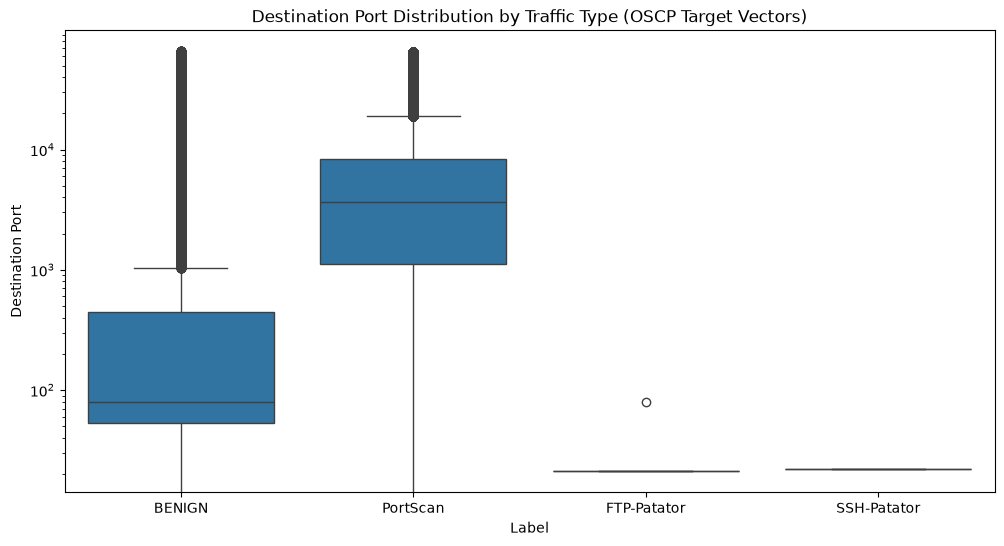

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/oscp_scope_traffic.csv") # Moving up one directory from /notebooks

df['Label'] = df['Label'].str.replace(r'\s*\ufffd\s*', ' - ', regex=True)
print("Cleaned Labels:\n", df['Label'].value_counts())

plt.figure(figsize=(12, 6))
# We filter for a few common categories to keep the plot readable
target_labels = ['BENIGN', 'PortScan', 'FTP-Patator', 'SSH-Patator']
filtered_df = df[df['Label'].isin(target_labels)]

sns.boxplot(data=filtered_df, x='Label', y='Destination Port')
plt.title('Destination Port Distribution by Traffic Type (OSCP Target Vectors)')
plt.yscale('log') # Log scale helps handle the massive range of ports (0-65535)
plt.show()

### Web Attacks - Brute Forcing, XSS, Sqli

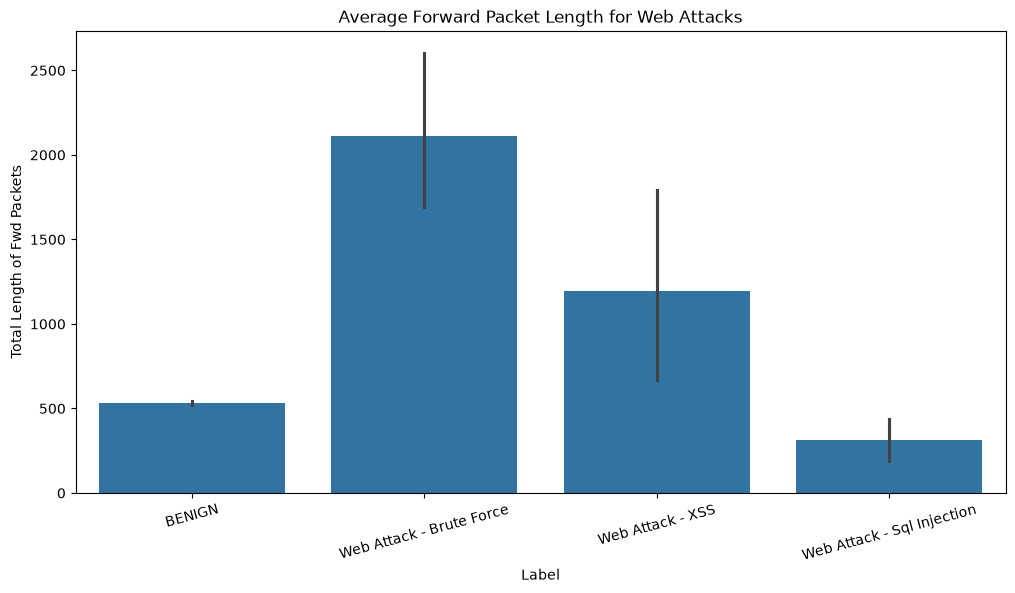

In [2]:
plt.figure(figsize=(12, 6))
web_labels = ['BENIGN', 'Web Attack - Brute Force', 'Web Attack - XSS', 'Web Attack - Sql Injection']
filtered_web = df[df['Label'].isin(web_labels)]

sns.barplot(data=filtered_web, x='Label', y='Total Length of Fwd Packets', estimator=lambda x: sum(x) / len(x))
plt.title('Average Forward Packet Length for Web Attacks')
plt.xticks(rotation=15)
plt.show()